In [41]:
import gc
import os
import shutil
import glob
from torchvision.transforms import v2
from climate_cnn import ClimateCNN
from swin_transformer import SwinTransformer
from utils.focal_loss import FocalLoss, soft_focal_loss
from utils.koppen_dataset import KoppenDataset
import torch
import tensorflow as tf
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split, KFold
import numpy as np
from tqdm.auto import tqdm
from utils.dataloader import load_shards
from utils.calculate_stats import calculate_stats
from utils.class_counts import get_class_counts
from utils.checkpoint import save_checkpoint
from utils.plots import plot_acc_loss, plot_per_class_f1, plot_confusion_matrix
from utils.multispectral_jitter import MultispectralJitter
from utils.cache import cache_shards_locally

In [42]:
# Fix random seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [43]:
# 1. Is CUDA available?
print(f"Is CUDA available? {torch.cuda.is_available()}")

# 2. Which version of CUDA was PyTorch built with?
print(f"PyTorch CUDA version: {torch.version.cuda}")

# 3. What is the name of your GPU?
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("PyTorch cannot find your GPU.")

# Set device to CUDA GPU if enabled
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Is CUDA available? True
PyTorch CUDA version: 12.8
GPU Name: NVIDIA GeForce RTX 3070


In [44]:
# Force TensorFlow to use CPU only so PyTorch has the whole GPU
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Verify TF doesn't see the GPU
print(tf.config.list_physical_devices('GPU')) # Should return []

[]


In [45]:
local_data_dir = '../data'
local_pattern = os.path.join(local_data_dir, 'koppen_shard_part_*.tfrecord.gz')
drive_pattern = r'G:/.shortcut-targets-by-id/1abX3CWvYUSJM3cGg6r_GeHAVeNoYH6Ul/CS6140_Project_Data/koppen_shard_part_*.tfrecord.gz'

# Check if files already exist in the local directory
all_files_cached = glob.glob(local_pattern)

if len(all_files_cached) > 0:
    print(f"Found {len(all_files_cached)} shards in local cache.")
else:
    # If local directory is empty, then access Google Drive
    print("Local cache empty. Accessing Google Drive to download shards...")
    all_files_drive = tf.io.gfile.glob(drive_pattern)

    if not all_files_drive:
        print("Warning: No files found on Google Drive. Verify the path and mounting.")
        all_files_cached = []
    else:
        # Use your caching function to copy them over
        all_files_cached = cache_shards_locally(all_files_drive, local_dir=local_data_dir)

print(len(all_files_cached), 'shards ready.')

# Split training, validation, and testing data
train_val_files, test_files = train_test_split(all_files_cached, test_size=0.1, random_state=SEED)
train_files, val_files = train_test_split(train_val_files, test_size=0.2, random_state=SEED)

# Save class counts locally
if not os.path.exists('class_counts.npy'):
    class_counts = get_class_counts(train_files)
    np.save('class_counts.npy', class_counts)

print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

Found 1500 shards in local cache.
1500 shards ready.
Train: 1080 | Val: 270 | Test: 150


In [46]:
# Load raw data to calculate normalization statistics
loader_batch_size = 256
clip_val = 4000

STATS_FILE = 'train_stats.npz'

# Calculate training dataset mean and std or get from stored results
if os.path.exists(STATS_FILE):
    print("Loading cached stats...")
    stats = np.load(STATS_FILE)
    train_means = stats['means'].tolist()
    train_stds = stats['stds'].tolist()
else:
    print("Computing stats...")
    train_raw = load_shards(train_files, batch_size=loader_batch_size)
    train_means, train_stds = calculate_stats(train_raw, clip_val=clip_val)
    np.savez(STATS_FILE, means=np.array(train_means), stds=np.array(train_stds))
    print("Stats cached to", STATS_FILE)

# Minimal transforms to perform on CPU
cpu_transforms = v2.Compose([
    # Clip to the same range used for stats
    v2.Lambda(lambda x: torch.clamp(x, 0, clip_val)),
    v2.ToDtype(torch.float32, scale=False),
])

# For Training: High variety to fight overfitting
train_gpu_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(180, interpolation=v2.InterpolationMode.BILINEAR),
    v2.RandomResizedCrop(128, scale=(0.8, 1.0), antialias=True),
    v2.Normalize(mean=train_means, std=train_stds),  # Normalizing on GPU is faster
    # MultispectralJitter(brightness=0.3, contrast=0.3)
])

# For Validation: No randomness
val_gpu_transforms = v2.Compose([
    v2.Resize(128, antialias=True),
    v2.Normalize(mean=train_means, std=train_stds)
])

# Create test dataloader
test_loader = DataLoader(
    KoppenDataset(load_shards(test_files, batch_size=loader_batch_size), cpu_transforms),
    batch_size=None,
    pin_memory=True
)

Loading cached stats...


In [47]:
# Training Loop Function
def train_model(
        model,
        train_dataloader,
        test_dataloader,
        criterion,
        optimizer,
        scheduler,
        class_weights=None,
        train_steps=None,
        num_epochs=10,
        start_epoch=0,
        best_val_acc=0,
        fold=None,
        patience=10,
        lr=1e-5,
        alpha=0.0
):
    model.to(device)
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    final_epoch = 0

    # Define grad scaler for float16 gradients
    scaler = torch.amp.GradScaler('cuda')

    training_losses = []
    training_accuracies = []
    validation_losses = []
    validation_accuracies = []

    class_names = [
        'Af', 'Am', 'Aw', 'BWh', 'BWk', 'BSh', 'BSk',
        'Csa', 'Csb', 'Csc', 'Cfa', 'Cfb', 'Cfc', 'Cwa', 'Cwb', 'Cwc',
        'Dsa', 'Dsb', 'Dsc', 'Dsd', 'Dfa', 'Dfb', 'Dfc', 'Dfd', 'Dwa', 'Dwb', 'Dwc', 'Dwd',
        'ET', 'EF'
    ]

    for epoch in range(start_epoch, num_epochs):
        # --- Training ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        progress_bar = tqdm(train_dataloader, total=train_steps, desc=f"Epoch {epoch + 1}/{num_epochs} [Train]")

        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)

            # Apply image augmentation
            images = train_gpu_transforms(images)

            # Apply a gradually increasing probability of applying mix-up to images and labels
            # (Linear ramp from epoch 5 to 20)
            mix_up_prob = min(1.0, max(0.0, (epoch - 4) / 15))

            if alpha > 0 and np.random.rand() < mix_up_prob:
                with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                    # Apply mix-up
                    lam = np.random.beta(alpha, alpha)
                    index = torch.randperm(images.size(0)).to(device)
                    mixed_images = lam * images + (1 - lam) * images[index, :]

                    # Convert integer labels to one-hot, then mix them
                    labels_onehot = torch.nn.functional.one_hot(labels, num_classes=30).float()
                    mixed_labels = lam * labels_onehot + (1 - lam) * labels_onehot[index, :]

                    outputs = model(mixed_images)
                    loss = soft_focal_loss(outputs, mixed_labels, alpha=class_weights, gamma=2.0)

                # Use dominant class as pseudo ground-truth for accuracy tracking
                _, primary_labels = mixed_labels.max(1)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += (predicted == primary_labels).sum().item()
            else:
                with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                    # Do not apply mix-up
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            # Backward pass
            scaler.scale(loss).backward()

            # Unscale gradients before clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()

            # Step the scheduler
            scheduler.step()

            # Loss statistics
            running_loss += loss.item() * images.size(0)

            # Update progress bar with current memory usage
            mem = torch.cuda.memory_reserved(0) / 1024**2
            progress_bar.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{100.*correct/total:.2f}%", "VRAM": f"{mem:.0f}MB"})

        # Append training loss/accuracy to plot data
        training_losses.append(running_loss / total)
        training_accuracies.append(100 * correct / total)

        # --- Validation ---
        model.eval()
        validation_loss = 0.0
        validation_correct = 0
        validation_total = 0

        all_predicted = []
        all_labels = []

        with torch.no_grad():
            for images, labels in test_dataloader:
                images, labels = images.to(device), labels.to(device)

                # Apply image resizing/normalization
                images = val_gpu_transforms(images)

                with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                validation_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                all_predicted.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                validation_total += labels.size(0)
                validation_correct += (predicted == labels).sum().item()

        # Plot confusion matrix for this epoch
        plot_confusion_matrix(
            all_labels,
            all_predicted,
            class_names,
            epoch + 1,
            fold,
            dirname=f"{type(model).__name__}"
                    f"_{type(criterion).__name__}"
                    f"_lr{lr}"
                    f"_a{alpha}"
                    f"_wd{optimizer.param_groups[0]['weight_decay']}"
        )

        avg_val_loss = validation_loss / validation_total
        current_val_acc = 100. * validation_correct / validation_total

        # Append validation loss/accuracy to plot data
        validation_losses.append(avg_val_loss)
        validation_accuracies.append(current_val_acc)

        # Check if this is the best version so far
        os.makedirs(f"models/{type(model).__name__}", exist_ok=True)
        if current_val_acc > best_val_acc:
            best_val_acc = current_val_acc
            save_checkpoint(
                {
                    'epoch': epoch + 1,
                    'state_dict': model.state_dict(),
                    'optimizer': optimizer.state_dict(),
                    'scheduler': scheduler.state_dict(),
                    'best_acc': best_val_acc,
                    'means': train_means,
                    'stds': train_stds
                },
                filename=f"models/{type(model).__name__}"
                         f"/checkpoint_{type(criterion).__name__}"
                         f"_lr{lr}"
                         f"_a{alpha}"
                         f"_wd{optimizer.param_groups[0]['weight_decay']}"
                         f"_fold{fold}.pth"
            )

        final_epoch = epoch + 1

        # Early stopping logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement == patience:
            print(f"{patience} epochs without validation loss improvement -- Early stopping triggered!")
            break

        print(f"--- Epoch {epoch + 1} Summary: Train Acc: {100. * correct / total:.2f}% | Val Acc: {current_val_acc:.2f}% ---")

    return training_losses, validation_losses, training_accuracies, validation_accuracies, final_epoch

In [48]:
def run_single_fold(
        model_type,
        files,
        fold,
        k,
        train_idx,
        val_idx,
        batch_size=64,
        lr=5e-5,
        weight_decay=0.05,
        alpha=0.0,
        num_epochs=20
):
    print(f"\n" + "="*30)
    print(f" STARTING FOLD {fold + 1} / {k} ")
    print("="*30)

    # Split shards for this fold
    train_files_fold = [files[i] for i in train_idx]
    val_files_fold = [files[i] for i in val_idx]

    # Initialize dataloaders using the same global train_means/train_stds calculated
    # previously (technically leakage, but sample size is large)
    train = load_shards(train_files_fold, batch_size=batch_size)
    val = load_shards(val_files_fold, batch_size=batch_size)

    fold_train_steps = sum(1 for _ in train.as_numpy_iterator())
    training_loader = DataLoader(
        KoppenDataset(train, cpu_transforms), batch_size=None, pin_memory=True
    )
    validation_loader = DataLoader(
        KoppenDataset(val, cpu_transforms), batch_size=None, pin_memory=True
    )

    # Reset model
    model = model_type(num_classes=30, in_channels=12)

    # Set up optimizer
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Define a linear ramp-up and cosine decay learning rate scheduler
    warmup_steps = int(0.3 * num_epochs * fold_train_steps)
    total_steps = num_epochs * fold_train_steps
    decay_steps = total_steps - warmup_steps

    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optim,
        start_factor=0.1,
        end_factor=1.0,
        total_iters=warmup_steps
    )

    decay_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optim,
        T_max=decay_steps,
        eta_min=1e-7  # Floor LR at end of training
    )

    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optim,
        schedulers=[warmup_scheduler, decay_scheduler],
        milestones=[warmup_steps]  # Step-count at which to switch schedulers
    )

    # Calculate log-smoothed weights (helps rare classes)
    counts = np.load('class_counts.npy')
    weights = 1.0 / np.log1p(counts)  # log1p for numerical safety
    weights = (weights / weights.sum()) * len(counts) # Normalize so mean weight is 1.0
    class_weights = torch.FloatTensor(weights).to(device)

    # Set up the loss function with the class weights
    loss_func = torch.nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

    # Reset confusion matrix plot directory
    shutil.rmtree(
        f'reports/'
        f'{type(model).__name__}'
        f'_{type(loss_func).__name__}'
        f'_lr{lr}'
        f'_a{alpha}'
        f'_wd{weight_decay}'
        f'/fold{fold}/cm',
        ignore_errors=True
    )

    # Train the model for this fold
    model_history = train_model(
        model=model,
        train_dataloader=training_loader,
        test_dataloader=validation_loader,
        train_steps=fold_train_steps,
        criterion=loss_func,
        optimizer=optim,
        scheduler=scheduler,
        class_weights=class_weights,
        num_epochs=num_epochs,
        fold=fold,
        patience=10,
        lr=lr,
        alpha=alpha
    )

    # Extract the best validation accuracy from this fold's history
    best_accuracy = max(model_history[3])

    print(f"\n>> Fold {fold + 1} Complete. Best Val Accuracy: {best_accuracy:.2f}%")

    plot_acc_loss(
        model_history,
        fold,
        f"{type(model).__name__}"
        f"_{type(loss_func).__name__}"
        f"_lr{lr}"
        f"_a{alpha}"
        f"_wd{weight_decay}"
    )
    plot_per_class_f1(
        model,
        fold,
        f"{type(model).__name__}"
        f"_{type(loss_func).__name__}"
        f"_lr{lr}"
        f"_a{alpha}"
        f"_wd{weight_decay}",
        test_loader,
        val_gpu_transforms
    )

    return model, best_accuracy, model_history

In [49]:
# K-Fold Cross Validation Function
def run_kfold(
        model_type,
        files,
        k=5,
        batch_size=64,
        lr=5e-5,
        weight_decay=0.05,
        alpha=0.0,
        num_epochs=20
):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    # To store the final performance of each fold
    all_fold_val_accuracies = []
    model_dict = {}

    for fold, (train_idx, val_idx) in enumerate(kf.split(files)):
        model_dict[fold] = list(
            run_single_fold(
                model_type,
                files,
                fold,
                k,
                train_idx,
                val_idx,
                batch_size=batch_size,
                lr=lr,
                weight_decay=weight_decay,
                alpha=alpha,
                num_epochs=num_epochs
            )
        )
        all_fold_val_accuracies.append(model_dict[fold][1])

    # Final Summary
    print(f"\n" + "!"*30)
    print(f"K-FOLD CROSS-VALIDATION COMPLETE")
    print(f"Average Accuracy: {np.mean(all_fold_val_accuracies):.2f}% (+/- {np.std(all_fold_val_accuracies):.2f}%)")
    print("!"*30)

    return model_dict


 STARTING FOLD 1 / 5 


Epoch 1/20 [Train]:   0%|          | 0/167 [00:00<?, ?it/s]

=> Saving best model to models/ClimateCNN/checkpoint_CrossEntropyLoss_lr0.0001_a0.0_wd1.0_fold0.pth
--- Epoch 1 Summary: Train Acc: 7.23% | Val Acc: 13.55% ---


Epoch 2/20 [Train]:   0%|          | 0/167 [00:00<?, ?it/s]

=> Saving best model to models/ClimateCNN/checkpoint_CrossEntropyLoss_lr0.0001_a0.0_wd1.0_fold0.pth
--- Epoch 2 Summary: Train Acc: 20.74% | Val Acc: 28.69% ---


...

=> Saving best model to models/ClimateCNN/checkpoint_CrossEntropyLoss_lr0.0001_a0.0_wd1.0_fold0.pth
--- Epoch 18 Summary: Train Acc: 76.98% | Val Acc: 64.21% ---


Epoch 19/20 [Train]:   0%|          | 0/167 [00:00<?, ?it/s]

--- Epoch 19 Summary: Train Acc: 77.41% | Val Acc: 63.82% ---


Epoch 20/20 [Train]:   0%|          | 0/167 [00:00<?, ?it/s]

=> Saving best model to models/ClimateCNN/checkpoint_CrossEntropyLoss_lr0.0001_a0.0_wd1.0_fold0.pth
--- Epoch 20 Summary: Train Acc: 78.03% | Val Acc: 64.25% ---

>> Fold 1 Complete. Best Val Accuracy: 64.25%


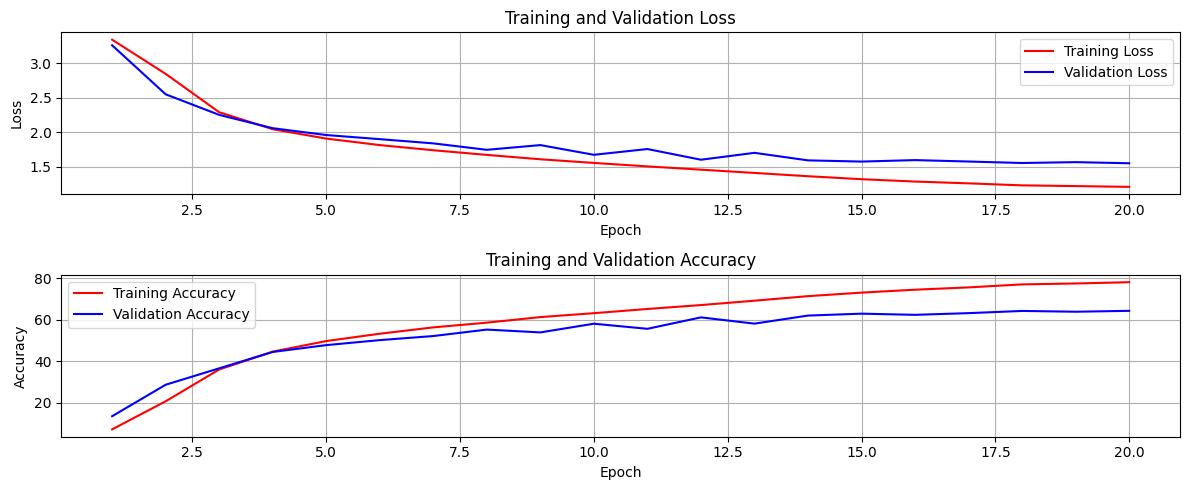

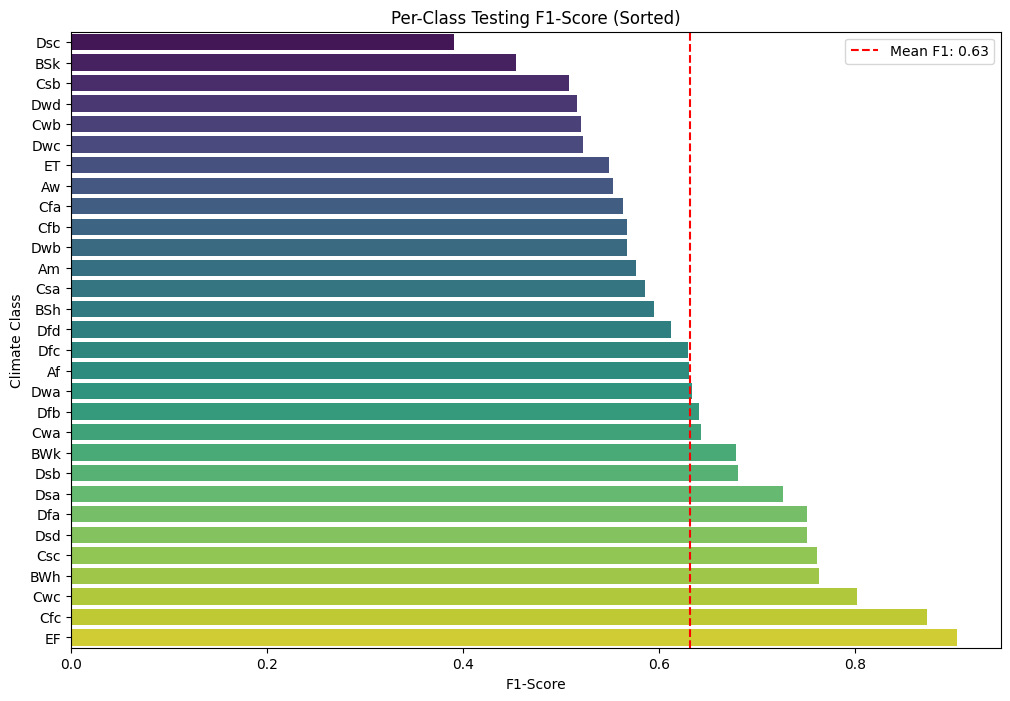

In [50]:
# Empty cache from previous runs
torch.cuda.empty_cache()
gc.collect()

epochs = 20

# # Execute the training
# models = run_kfold(SwinTransformer, train_val_files, k=5, lr=5e-5, weight_decay=0.05, num_epochs=epochs)
#
# # Get the best model
# trained_model, best_acc, history = max(models.values(), key=lambda x: x[1])

# Train on just one fold
k_folds = KFold(n_splits=5, shuffle=True, random_state=42)
folds = list(k_folds.split(train_val_files))
train_index, val_index = folds[0]

trained_model, best_acc, history = run_single_fold(
    model_type=ClimateCNN,
    files=train_val_files,
    fold=0,
    k=5,
    train_idx=train_index,
    val_idx=val_index,
    batch_size=256,
    lr=1e-4,
    weight_decay=1.0,
    alpha=0.0,
    num_epochs=epochs
)

# Save best model
os.makedirs(f"models/{type(trained_model).__name__}", exist_ok=True)
torch.save(trained_model.state_dict(), f"models/{type(trained_model).__name__}/best.pth")